In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/raw/train.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

df = df.sort_values(
    ["store", "item", "date"]
).reset_index(drop=True)

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [2]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [3]:
group = df.groupby(["store", "item"])["sales"]

df["lag_1"] = group.shift(1)
df["lag_7"] = group.shift(7)
df["lag_14"] = group.shift(14)
df["lag_28"] = group.shift(28)

In [4]:
df[
    ["date", "store", "item", "sales",
     "lag_1", "lag_7", "lag_14", "lag_28"]
].head(35)

,date,store,item,sales,lag_1,lag_7,lag_14,lag_28
0,2013-01-01,1,1,13,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,13.0,NaN,NaN,NaN
2,2013-01-03,1,1,14,11.0,NaN,NaN,NaN
3,2013-01-04,1,1,13,14.0,NaN,NaN,NaN
4,2013-01-05,1,1,10,13.0,NaN,NaN,NaN
5,2013-01-06,1,1,12,10.0,NaN,NaN,NaN
6,2013-01-07,1,1,10,12.0,NaN,NaN,NaN
7,2013-01-08,1,1,9,10.0,13.0,NaN,NaN
8,2013-01-09,1,1,12,9.0,11.0,NaN,NaN
9,2013-01-10,1,1,9,12.0,14.0,NaN,NaN


In [5]:
group = df.groupby(["store", "item"])["sales"]

df["rolling_mean_7"] = group.transform(
    lambda x: x.shift(1).rolling(7).mean()
)

df["rolling_mean_14"] = group.transform(
    lambda x: x.shift(1).rolling(14).mean()
)

df["rolling_mean_28"] = group.transform(
    lambda x: x.shift(1).rolling(28).mean()
)

df["rolling_std_7"] = group.transform(
    lambda x: x.shift(1).rolling(7).std()
)

df["rolling_std_28"] = group.transform(
    lambda x: x.shift(1).rolling(28).std()
)

In [6]:
df[
    (df["store"] == 1) &
    (df["item"] == 1)
][
    [
        "date",
        "sales",
        "lag_1",
        "lag_7",
        "rolling_mean_7"
    ]
].head(15)

,date,sales,lag_1,lag_7,rolling_mean_7
0,2013-01-01,13,NaN,NaN,NaN
1,2013-01-02,11,13.0,NaN,NaN
2,2013-01-03,14,11.0,NaN,NaN
3,2013-01-04,13,14.0,NaN,NaN
4,2013-01-05,10,13.0,NaN,NaN
5,2013-01-06,12,10.0,NaN,NaN
6,2013-01-07,10,12.0,NaN,NaN
7,2013-01-08,9,10.0,13.0,11.857143
8,2013-01-09,12,9.0,11.0,11.285714
9,2013-01-10,9,12.0,14.0,11.428571


In [8]:
df_model = df.dropna().copy()

print(f"Original rows: {len(df):,}")
print(f"Modeling rows: {len(df_model):,}")

Original rows: 913,000
Modeling rows: 899,000


In [9]:
TARGET = "sales"

In [10]:
FEATURES = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]

In [12]:
X = df_model[FEATURES]
y = df_model[TARGET]

In [13]:
X.shape, y.shape

((899000, 18), (899000,))

In [15]:
train = df_model[
    df_model["date"] < "2017-01-01"
].copy()

validation = df_model[
    (df_model["date"] >= "2017-01-01") &
    (df_model["date"] < "2017-10-01")
].copy()

test = df_model[
    df_model["date"] >= "2017-10-01"
].copy()

In [16]:
print("Train:")
print(train["date"].min(), "→", train["date"].max())
print(f"{len(train):,} rows")

print("\nValidation:")
print(validation["date"].min(), "→", validation["date"].max())
print(f"{len(validation):,} rows")

print("\nTest:")
print(test["date"].min(), "→", test["date"].max())
print(f"{len(test):,} rows")

Train:
2013-01-29 00:00:00 → 2016-12-31 00:00:00
716,500 rows

Validation:
2017-01-01 00:00:00 → 2017-09-30 00:00:00
136,500 rows

Test:
2017-10-01 00:00:00 → 2017-12-31 00:00:00
46,000 rows


In [17]:
validation["prediction_baseline"] = validation["lag_7"]

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [19]:
mae = mean_absolute_error(
    validation["sales"],
    validation["prediction_baseline"]
)

rmse = np.sqrt(
    mean_squared_error(
        validation["sales"],
        validation["prediction_baseline"]
    )
)

print(f"Baseline MAE:  {mae:.3f}")
print(f"Baseline RMSE: {rmse:.3f}")

Baseline MAE:  8.762
Baseline RMSE: 11.440


In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_val = validation[FEATURES]
y_val = validation[TARGET]

In [22]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

In [23]:
rf_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [24]:
rf_predictions = rf_model.predict(X_val)

In [25]:
rf_mae = mean_absolute_error(
    y_val,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_predictions
    )
)

print(f"Random Forest MAE:  {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")

Random Forest MAE:  6.312
Random Forest RMSE: 8.216


In [26]:
results = pd.DataFrame({
    "Model": [
        "Seasonal Naive (lag 7)",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ]
})

results

,Model,MAE,RMSE
0,Seasonal Naive (lag 7),8.762300,11.439668
1,Random Forest,6.311707,8.216360


In [27]:
feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
13,rolling_mean_7,0.604212
10,lag_7,0.192940
14,rolling_mean_14,0.121970
11,lag_14,0.021259
9,lag_1,0.017789
5,day_of_week,0.017390
15,rolling_mean_28,0.004049
12,lag_28,0.003965
4,day,0.003767
6,week_of_year,0.003449


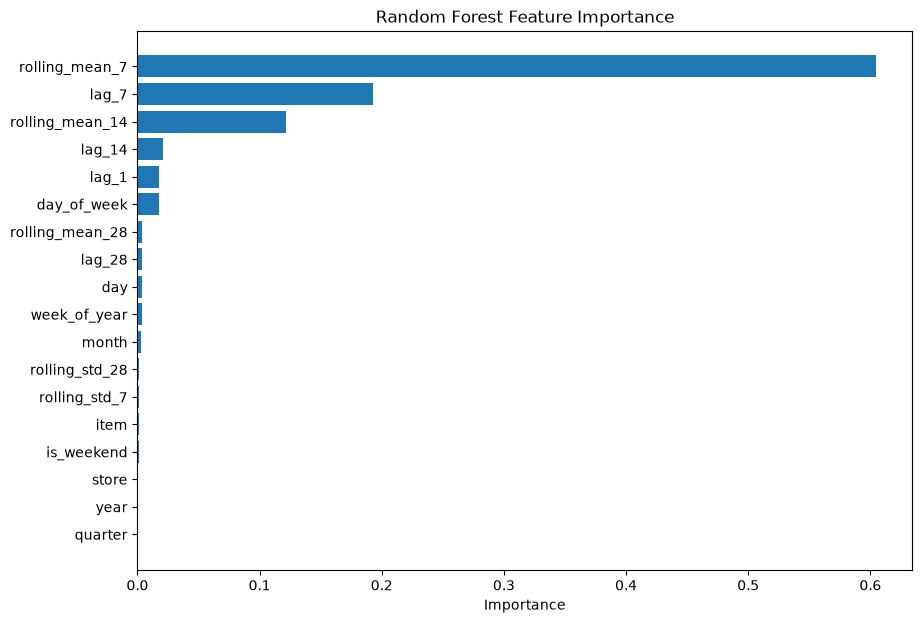

In [28]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

In [29]:
OUTPUT_PATH = Path(
    "../data/processed/features.csv"
)

df_model.to_csv(
    OUTPUT_PATH,
    index=False
)

¿en qué se equivoca el random forest?

In [30]:
validation["prediction_rf"] = rf_predictions

validation["absolute_error_rf"] = np.abs(
    validation["sales"] - validation["prediction_rf"]
)

validation["absolute_error_baseline"] = np.abs(
    validation["sales"] - validation["prediction_baseline"]
)

In [31]:
error_by_store = (
    validation
    .groupby("store")
    .agg(
        actual_sales=("sales", "mean"),
        baseline_mae=("absolute_error_baseline", "mean"),
        rf_mae=("absolute_error_rf", "mean")
    )
)

error_by_store["improvement_pct"] = (
    (error_by_store["baseline_mae"] - error_by_store["rf_mae"])
    / error_by_store["baseline_mae"]
    * 100
)

error_by_store

,actual_sales,baseline_mae,rf_mae,improvement_pct
store,,,,
1,54.490623,8.388938,6.026783,28.157966
2,77.157143,10.043956,7.262503,27.692806
3,68.689817,9.385201,6.775479,27.806784
4,63.260659,9.242344,6.598385,28.607016
5,45.864908,7.577582,5.466280,27.862480
6,45.770769,7.550330,5.466749,27.595893
7,41.911795,7.219414,5.203927,27.917600
8,73.859121,9.832674,7.068352,28.113631
9,63.465714,8.975165,6.480100,27.799651


In [32]:
error_by_item = (
    validation
    .groupby("item")
    .agg(
        actual_sales=("sales", "mean"),
        baseline_mae=("absolute_error_baseline", "mean"),
        rf_mae=("absolute_error_rf", "mean")
    )
)

error_by_item["improvement_pct"] = (
    (error_by_item["baseline_mae"] - error_by_item["rf_mae"])
    / error_by_item["baseline_mae"]
    * 100
)

error_by_item.sort_values("rf_mae", ascending=False).head(10)

,actual_sales,baseline_mae,rf_mae,improvement_pct
item,,,,
15,101.343223,11.907692,8.580478,27.941725
28,101.101099,12.028205,8.566648,28.778665
18,97.204029,11.889744,8.460625,28.840981
13,97.290476,11.429670,8.364106,26.821108
38,92.637363,11.126007,8.207007,26.235831
22,92.443956,11.483516,8.104840,29.421966
45,93.198535,11.180220,8.038399,28.101600
25,92.787179,10.923810,8.014858,26.629458
36,88.545421,11.079487,7.896125,28.732040


In [33]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---- ----------------------------------- 5.2/48.9 MB 25.8 MB/s eta 0:00:02
   ------ --------------------------------- 7.9/48.9 MB 18.8 MB/s eta 0:00:03
   ---------- ----------------------------- 12.6/48.9 MB 20.2 MB/s eta 0:00:02
   -------------- ------------------------- 17.8/48.9 MB 22.1 MB/s eta 0:00:02
   ---------------- ----------------------- 20.4/48.9 MB 20.0 MB/s eta 0:00:02
   ----------------- ---------------------- 22.0/48.9 MB 17.9 MB/s eta 0:00:02
   ----------------------- ---------------- 28.8/48.9 MB 20.1 MB/s eta 0:00:02
   ---------------------------- ----------- 34.3/48.9 MB 20.7 MB/s eta 0:00:01
   -------------------------------- ------- 39.8/48.9 MB 21.2 MB/s eta 0:00:01
   ------------------------------------ --- 45.1/48.9 MB 21.6 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 21.8 MB/s eta 0

In [34]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [35]:
from xgboost import XGBRegressor

In [36]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

In [37]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [38]:
xgb_predictions = xgb_model.predict(X_val)

Evaluación

In [39]:
xgb_mae = mean_absolute_error(
    y_val,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_predictions
    )
)

print(f"XGBoost MAE:  {xgb_mae:.3f}")
print(f"XGBoost RMSE: {xgb_rmse:.3f}")

XGBoost MAE:  6.156
XGBoost RMSE: 8.012


In [40]:
results = pd.DataFrame({
    "Model": [
        "Seasonal Naive (lag 7)",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results

,Model,MAE,RMSE
0,Seasonal Naive (lag 7),8.762300,11.439668
1,Random Forest,6.311707,8.216360
2,XGBoost,6.156199,8.012353


In [41]:
results["MAE_improvement_vs_baseline_pct"] = (
    (mae - results["MAE"])
    / mae
    * 100
)

results

,Model,MAE,RMSE,MAE_improvement_vs_baseline_pct
0,Seasonal Naive (lag 7),8.762300,11.439668,0.000000
1,Random Forest,6.311707,8.216360,27.967463
2,XGBoost,6.156199,8.012353,29.742211


In [42]:
xgb_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

xgb_importance

,feature,importance
13,rolling_mean_7,0.426853
14,rolling_mean_14,0.230600
10,lag_7,0.140405
8,is_weekend,0.046835
15,rolling_mean_28,0.046439
5,day_of_week,0.040793
11,lag_14,0.032109
9,lag_1,0.010323
3,month,0.006844
12,lag_28,0.006157


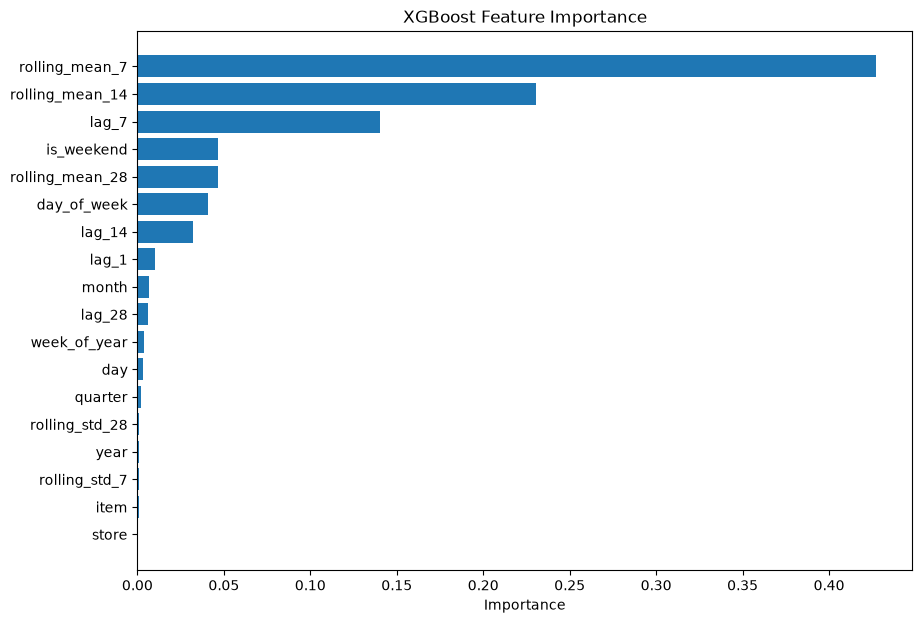

In [43]:
plt.figure(figsize=(10, 7))

plt.barh(
    xgb_importance["feature"],
    xgb_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [44]:
def wape(y_true, y_pred):
    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
        * 100
    )

In [45]:
baseline_wape = wape(
    y_val.to_numpy(),
    validation["prediction_baseline"].to_numpy()
)

rf_wape = wape(
    y_val.to_numpy(),
    rf_predictions
)

xgb_wape = wape(
    y_val.to_numpy(),
    xgb_predictions
)

print(f"Baseline WAPE:      {baseline_wape:.2f}%")
print(f"Random Forest WAPE: {rf_wape:.2f}%")
print(f"XGBoost WAPE:       {xgb_wape:.2f}%")

Baseline WAPE:      14.55%
Random Forest WAPE: 10.48%
XGBoost WAPE:       10.22%


In [46]:
example = validation[
    (validation["store"] == 1) &
    (validation["item"] == 1)
].copy()

example["prediction_rf"] = rf_model.predict(
    example[FEATURES]
)

example["prediction_xgb"] = xgb_model.predict(
    example[FEATURES]
)

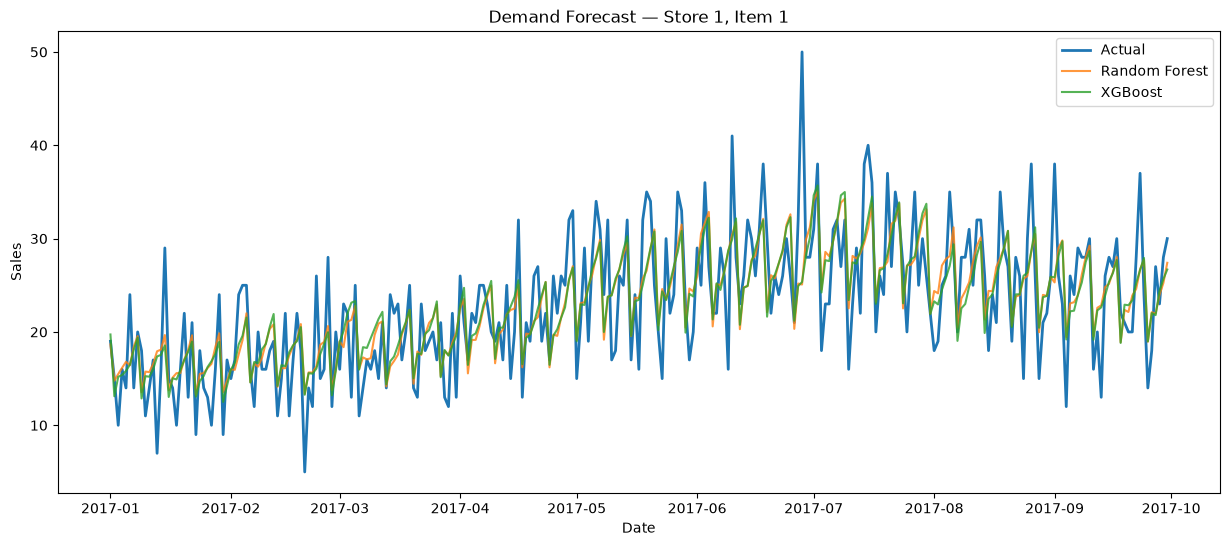

In [47]:
plt.figure(figsize=(15, 6))

plt.plot(
    example["date"],
    example["sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    example["date"],
    example["prediction_rf"],
    label="Random Forest",
    alpha=0.8
)

plt.plot(
    example["date"],
    example["prediction_xgb"],
    label="XGBoost",
    alpha=0.8
)

plt.title("Demand Forecast — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

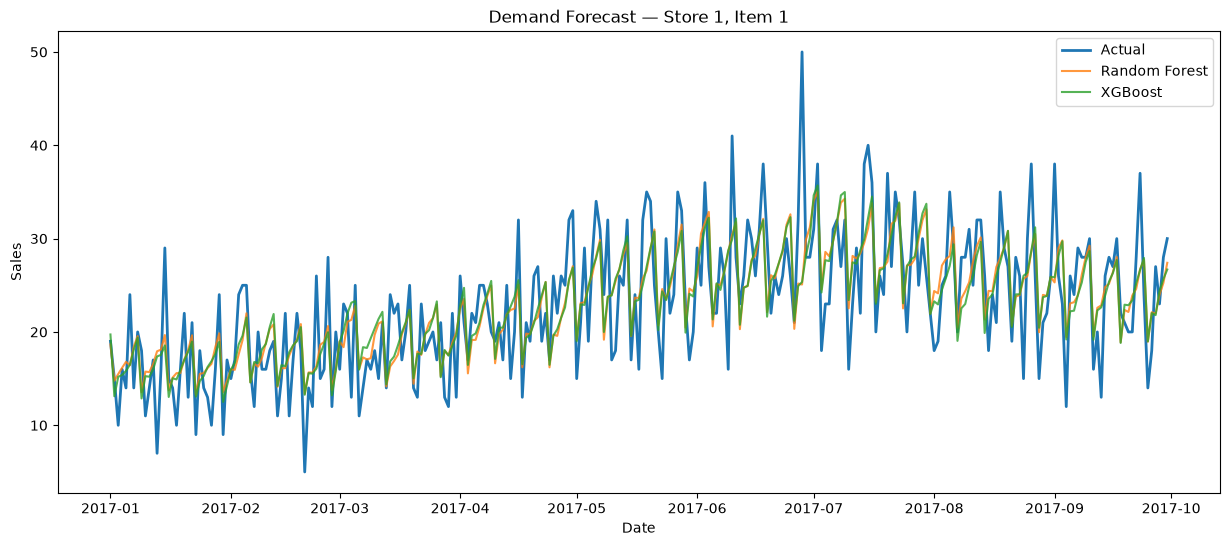

In [48]:
plt.figure(figsize=(15, 6))

plt.plot(
    example["date"],
    example["sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    example["date"],
    example["prediction_rf"],
    label="Random Forest",
    alpha=0.8
)

plt.plot(
    example["date"],
    example["prediction_xgb"],
    label="XGBoost",
    alpha=0.8
)

plt.title("Demand Forecast — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [49]:
folds = [
    {
        "name": "2015_Q1",
        "train_end": "2015-01-01",
        "val_start": "2015-01-01",
        "val_end": "2015-04-01"
    },
    {
        "name": "2016_Q1",
        "train_end": "2016-01-01",
        "val_start": "2016-01-01",
        "val_end": "2016-04-01"
    },
    {
        "name": "2017_Q1",
        "train_end": "2017-01-01",
        "val_start": "2017-01-01",
        "val_end": "2017-04-01"
    }
]

In [50]:
cv_results = []

for fold in folds:

    fold_train = df_model[
        df_model["date"] < fold["train_end"]
    ]

    fold_val = df_model[
        (df_model["date"] >= fold["val_start"]) &
        (df_model["date"] < fold["val_end"])
    ]

    X_fold_train = fold_train[FEATURES]
    y_fold_train = fold_train[TARGET]

    X_fold_val = fold_val[FEATURES]
    y_fold_val = fold_val[TARGET]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_val
    )

    fold_mae = mean_absolute_error(
        y_fold_val,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_fold_val,
            predictions
        )
    )

    fold_wape = wape(
        y_fold_val.to_numpy(),
        predictions
    )

    cv_results.append({
        "fold": fold["name"],
        "train_rows": len(fold_train),
        "validation_rows": len(fold_val),
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "WAPE": fold_wape
    })

In [51]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,fold,train_rows,validation_rows,MAE,RMSE,WAPE
0,2015_Q1,351000,45000,5.144609,6.668730,12.617715
1,2016_Q1,533500,45500,5.284949,6.863918,11.973706
2,2017_Q1,716500,45000,5.363262,6.950230,11.708235


In [52]:
print(
    "Average MAE:",
    cv_results_df["MAE"].mean()
)

print(
    "Average RMSE:",
    cv_results_df["RMSE"].mean()
)

print(
    "Average WAPE:",
    cv_results_df["WAPE"].mean()
)

Average MAE: 5.264273484547933
Average RMSE: 6.827626149437431
Average WAPE: 12.099885359400963


In [53]:
print(
    "Average MAE:",
    cv_results_df["MAE"].mean()
)

print(
    "Average RMSE:",
    cv_results_df["RMSE"].mean()
)

print(
    "Average WAPE:",
    cv_results_df["WAPE"].mean()
)

Average MAE: 5.264273484547933
Average RMSE: 6.827626149437431
Average WAPE: 12.099885359400963


In [54]:
baseline_predictions = fold_val["lag_7"]

baseline_mae_fold = mean_absolute_error(
    y_fold_val,
    baseline_predictions
)

baseline_wape_fold = wape(
    y_fold_val.to_numpy(),
    baseline_predictions.to_numpy()
)

In [55]:
cv_results.append({
    "fold": fold["name"],

    "train_rows": len(fold_train),
    "validation_rows": len(fold_val),

    "baseline_MAE": baseline_mae_fold,
    "xgb_MAE": fold_mae,

    "baseline_WAPE": baseline_wape_fold,
    "xgb_WAPE": fold_wape
})

In [56]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df["improvement_pct"] = (
    (
        cv_results_df["baseline_MAE"]
        - cv_results_df["xgb_MAE"]
    )
    / cv_results_df["baseline_MAE"]
    * 100
)

cv_results_df

,fold,train_rows,validation_rows,MAE,RMSE,WAPE,baseline_MAE,xgb_MAE,baseline_WAPE,xgb_WAPE,improvement_pct
0,2015_Q1,351000,45000,5.144609,6.668730,12.617715,NaN,NaN,NaN,NaN,NaN
1,2016_Q1,533500,45500,5.284949,6.863918,11.973706,NaN,NaN,NaN,NaN,NaN
2,2017_Q1,716500,45000,5.363262,6.950230,11.708235,NaN,NaN,NaN,NaN,NaN
3,2017_Q1,716500,45000,NaN,NaN,NaN,7.680111,5.363262,16.766019,11.708235,30.166874


In [57]:
cv_results = []

for fold in folds:

    # -------------------------
    # Train / validation split
    # -------------------------

    fold_train = df_model[
        df_model["date"] < fold["train_end"]
    ].copy()

    fold_val = df_model[
        (df_model["date"] >= fold["val_start"]) &
        (df_model["date"] < fold["val_end"])
    ].copy()

    X_fold_train = fold_train[FEATURES]
    y_fold_train = fold_train[TARGET]

    X_fold_val = fold_val[FEATURES]
    y_fold_val = fold_val[TARGET]

    # -------------------------
    # XGBoost
    # -------------------------

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    xgb_predictions_fold = model.predict(
        X_fold_val
    )

    # -------------------------
    # XGBoost metrics
    # -------------------------

    xgb_mae_fold = mean_absolute_error(
        y_fold_val,
        xgb_predictions_fold
    )

    xgb_rmse_fold = np.sqrt(
        mean_squared_error(
            y_fold_val,
            xgb_predictions_fold
        )
    )

    xgb_wape_fold = wape(
        y_fold_val.to_numpy(),
        xgb_predictions_fold
    )

    # -------------------------
    # Seasonal naive baseline
    # -------------------------

    baseline_predictions_fold = fold_val["lag_7"]

    baseline_mae_fold = mean_absolute_error(
        y_fold_val,
        baseline_predictions_fold
    )

    baseline_rmse_fold = np.sqrt(
        mean_squared_error(
            y_fold_val,
            baseline_predictions_fold
        )
    )

    baseline_wape_fold = wape(
        y_fold_val.to_numpy(),
        baseline_predictions_fold.to_numpy()
    )

    # -------------------------
    # Save fold
    # -------------------------

    cv_results.append({
        "fold": fold["name"],
        "train_rows": len(fold_train),
        "validation_rows": len(fold_val),

        "baseline_MAE": baseline_mae_fold,
        "xgb_MAE": xgb_mae_fold,

        "baseline_RMSE": baseline_rmse_fold,
        "xgb_RMSE": xgb_rmse_fold,

        "baseline_WAPE": baseline_wape_fold,
        "xgb_WAPE": xgb_wape_fold
    })

In [58]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df["MAE_improvement_pct"] = (
    (
        cv_results_df["baseline_MAE"]
        - cv_results_df["xgb_MAE"]
    )
    / cv_results_df["baseline_MAE"]
    * 100
)

cv_results_df["WAPE_improvement_pct"] = (
    (
        cv_results_df["baseline_WAPE"]
        - cv_results_df["xgb_WAPE"]
    )
    / cv_results_df["baseline_WAPE"]
    * 100
)

cv_results_df.round(3)

,fold,train_rows,validation_rows,baseline_MAE,xgb_MAE,baseline_RMSE,xgb_RMSE,baseline_WAPE,xgb_WAPE,MAE_improvement_pct,WAPE_improvement_pct
0,2015_Q1,351000,45000,7.197,5.145,9.384,6.669,17.650,12.618,28.513,28.513
1,2016_Q1,533500,45500,7.494,5.285,9.761,6.864,16.979,11.974,29.479,29.479
2,2017_Q1,716500,45000,7.680,5.363,10.007,6.950,16.766,11.708,30.167,30.167


In [59]:
summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "WAPE"
    ],

    "Baseline Mean": [
        cv_results_df["baseline_MAE"].mean(),
        cv_results_df["baseline_RMSE"].mean(),
        cv_results_df["baseline_WAPE"].mean()
    ],

    "XGBoost Mean": [
        cv_results_df["xgb_MAE"].mean(),
        cv_results_df["xgb_RMSE"].mean(),
        cv_results_df["xgb_WAPE"].mean()
    ],

    "XGBoost Std": [
        cv_results_df["xgb_MAE"].std(),
        cv_results_df["xgb_RMSE"].std(),
        cv_results_df["xgb_WAPE"].std()
    ]
})

summary.round(3)

,Metric,Baseline Mean,XGBoost Mean,XGBoost Std
0,MAE,7.457,5.264,0.111
1,RMSE,9.717,6.828,0.144
2,WAPE,17.132,12.100,0.468


In [60]:
final_train = df_model[
    df_model["date"] < "2017-10-01"
].copy()

final_test = df_model[
    df_model["date"] >= "2017-10-01"
].copy()

print("Final training period:")
print(
    final_train["date"].min(),
    "→",
    final_train["date"].max()
)

print("\nFinal test period:")
print(
    final_test["date"].min(),
    "→",
    final_test["date"].max()
)

print(f"\nTraining rows: {len(final_train):,}")
print(f"Test rows: {len(final_test):,}")

Final training period:
2013-01-29 00:00:00 → 2017-09-30 00:00:00

Final test period:
2017-10-01 00:00:00 → 2017-12-31 00:00:00

Training rows: 853,000
Test rows: 46,000


In [61]:
X_final_train = final_train[FEATURES]
y_final_train = final_train[TARGET]

X_final_test = final_test[FEATURES]
y_final_test = final_test[TARGET]

In [62]:
final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

final_model.fit(
    X_final_train,
    y_final_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [64]:
final_predictions = final_model.predict(
    X_final_test
)

In [65]:
final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_predictions
    )
)

final_wape = wape(
    y_final_test.to_numpy(),
    final_predictions
)

print(f"FINAL TEST MAE:  {final_mae:.3f}")
print(f"FINAL TEST RMSE: {final_rmse:.3f}")
print(f"FINAL TEST WAPE: {final_wape:.2f}%")

FINAL TEST MAE:  5.935
FINAL TEST RMSE: 7.677
FINAL TEST WAPE: 10.86%


In [66]:
final_baseline_predictions = final_test["lag_7"]

final_baseline_mae = mean_absolute_error(
    y_final_test,
    final_baseline_predictions
)

final_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_baseline_predictions
    )
)

final_baseline_wape = wape(
    y_final_test.to_numpy(),
    final_baseline_predictions.to_numpy()
)

print(f"Baseline MAE:  {final_baseline_mae:.3f}")
print(f"Baseline RMSE: {final_baseline_rmse:.3f}")
print(f"Baseline WAPE: {final_baseline_wape:.2f}%")

Baseline MAE:  9.076
Baseline RMSE: 12.051
Baseline WAPE: 16.60%


In [67]:
final_results = pd.DataFrame({
    "Model": [
        "Seasonal Naive (lag 7)",
        "XGBoost"
    ],

    "MAE": [
        final_baseline_mae,
        final_mae
    ],

    "RMSE": [
        final_baseline_rmse,
        final_rmse
    ],

    "WAPE": [
        final_baseline_wape,
        final_wape
    ]
})

final_results["MAE_improvement_pct"] = (
    (final_baseline_mae - final_results["MAE"])
    / final_baseline_mae
    * 100
)

final_results.round(3)

,Model,MAE,RMSE,WAPE,MAE_improvement_pct
0,Seasonal Naive (lag 7),9.076,12.051,16.600,0.000
1,XGBoost,5.935,7.677,10.855,34.607


In [68]:
final_test["prediction"] = final_predictions

final_test["absolute_error"] = np.abs(
    final_test["sales"]
    - final_test["prediction"]
)

test_store_performance = (
    final_test
    .groupby("store")
    .agg(
        mean_sales=("sales", "mean"),
        MAE=("absolute_error", "mean")
    )
    .sort_values("MAE")
)

test_store_performance

,mean_sales,MAE
store,,
7,38.057174,4.914145
6,41.542609,5.153229
5,41.514130,5.215093
1,49.560217,5.638706
4,57.378696,6.138656
9,57.663043,6.196033
10,61.224783,6.197665
3,62.250000,6.355003
8,67.325870,6.716126


In [69]:
final_test["residual"] = (
    final_test["sales"]
    - final_test["prediction"]
)

In [70]:
final_test["residual"].describe()

count    46000.000000
mean         0.031881
std          7.677116
min        -37.211212
25%         -4.846968
50%         -0.184441
75%          4.665234
max         37.821693
Name: residual, dtype: float64

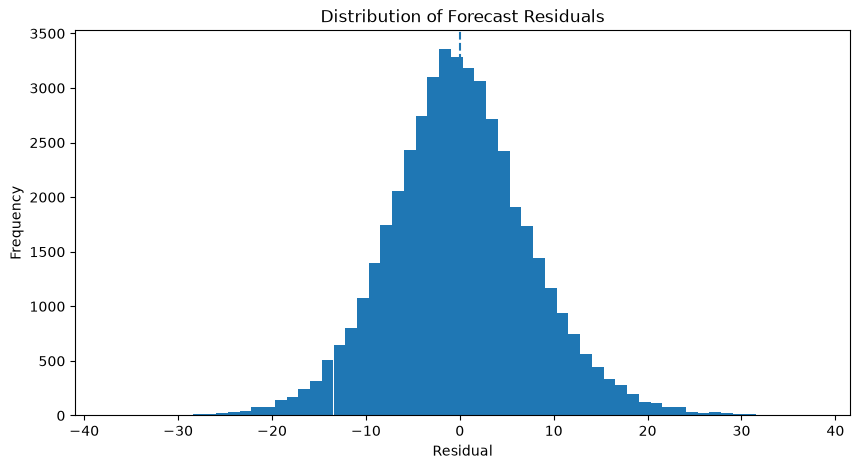

In [71]:
plt.figure(figsize=(10, 5))

plt.hist(
    final_test["residual"],
    bins=60
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Forecast Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

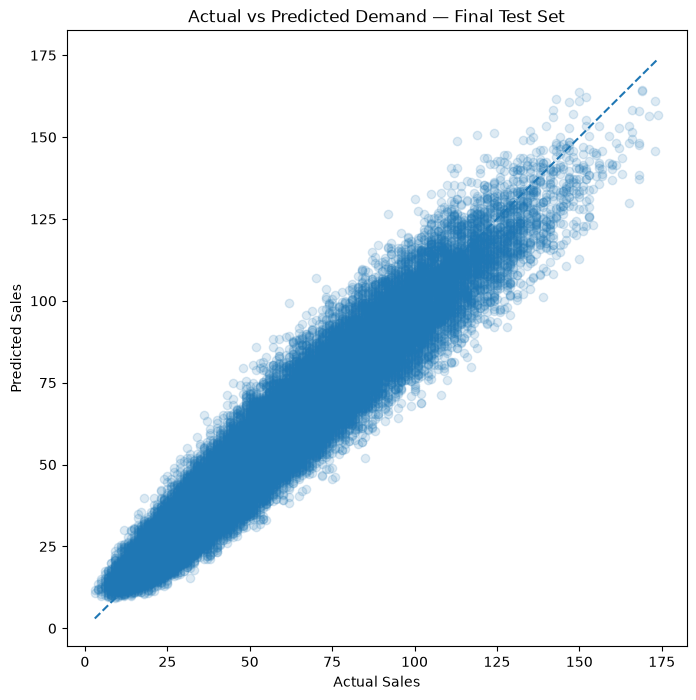

In [72]:
plt.figure(figsize=(8, 8))

plt.scatter(
    final_test["sales"],
    final_test["prediction"],
    alpha=0.15
)

minimum = min(
    final_test["sales"].min(),
    final_test["prediction"].min()
)

maximum = max(
    final_test["sales"].max(),
    final_test["prediction"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Demand — Final Test Set"
)

plt.show()

In [73]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [74]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [75]:
import joblib

In [76]:
MODEL_PATH = "../models/xgboost_demand_forecaster.joblib"

joblib.dump(
    final_model,
    MODEL_PATH
)

['../models/xgboost_demand_forecaster.joblib']

In [77]:
loaded_model = joblib.load(
    MODEL_PATH
)

test_prediction = loaded_model.predict(
    X_final_test.iloc[:5]
)

test_prediction

array([26.667715, 17.870897, 20.736118, 20.423536, 21.695503],
      dtype=float32)

In [78]:
final_predictions[:5]

array([26.667715, 17.870897, 20.736118, 20.423536, 21.695503],
      dtype=float32)